In [1]:
BASE = r"C:\Projects\PLFS"

In [2]:
pip install openpyxl pandas numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import sys
!{sys.executable} -m pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import os
os.chdir(r"C:\Projects\PLFS")
print(os.getcwd())
print(os.listdir())

C:\Projects\PLFS
['01_data_ingestion_01.ipynb', 'egi_sii_bars.png', 'egi_sii_by_year.png', 'egi_sii_trendlines.png', 'egi_vs_sii.png', 'ilmsi_bar.png', 'ilmsi_by_year.png', 'ilmsi_scatter.png', 'PLFS 22-23 tables', 'PLFS 23-24 tables', 'PLFS 25 tables', 'plfs_ilmsi.csv', 'plfs_master_panel.csv', 'Table29.6-States.xlsx']


In [ ]:
import pandas as pd
import numpy as np
import os
import glob

BASE = r"C:\Projects\PLFS"

YEARS = {
    "2022_23": {"folder": os.path.join(BASE, "PLFS 22-23 tables"), "prefix": "PLFS 22-23"},
    "2023_24": {"folder": os.path.join(BASE, "PLFS 23-24 tables"), "prefix": "PLFS 23-24"},
    "2025":    {"folder": os.path.join(BASE, "PLFS 25 tables"),    "prefix": "PLFS 25"},
}

FILES = [
    "LFPR", "WPR", "EMP STATUS", "INDUSTRY",
    "ENTERPRISE", "WAGE REGULAR", "WAGE CASUAL",
    "WAGE SELF", "HOURS"
]

def get_path(year_key, file_key):
    info = YEARS[year_key]
    return os.path.join(info["folder"], f"{info['prefix']} {file_key}.xlsx")

all_ok = True
for year in YEARS:
    for f in FILES:
        p = get_path(year, f)
        if not os.path.exists(p):
            print(f"MISSING: {p}")
            all_ok = False

if all_ok:
    print("All 27 files found. Ready to proceed.")

All 27 files found. Ready to proceed.


In [ ]:
def extract_last_subtable(filepath, value_col=9):
    """
    Every PLFS table file contains multiple sub-tables stacked vertically.
    The sub-tables go: rural male, rural female, rural persons,
                       urban male, urban female, urban persons,
                       rural+urban male, rural+urban female, rural+urban persons.
    We always want the LAST sub-table (rural+urban persons, all ages).
    value_col=9 corresponds to the 'person' column under 'rural+urban'.
    """
    df_raw = pd.read_excel(filepath, header=None, sheet_name=0)
    rows = df_raw.values.tolist()

    
    starts = [i for i, row in enumerate(rows)
               if isinstance(row[0], str) and 'Table' in row[0]]

    if not starts:
        raise ValueError(f"No sub-tables found in {filepath}")


    last_start = starts[-1]
    block = rows[last_start:]

  
    skip_strings = {'state/ut', 'state \\ut', '(1)', 'male', 'female', 'person',
                    'rural', 'urban', 'rural + urban', 'rural+urban'}

    data = []
    for row in block:
        cell = row[0]
        if not isinstance(cell, str):
            continue
        cell_clean = cell.strip()
        if not cell_clean:
            continue
        if cell_clean.lower() in skip_strings:
            continue
        if any(kw in cell_clean.lower() for kw in ['table', 'rural', 'urban', 'male', 'female', 'note']):
            continue
        try:
            val = float(row[value_col])
        except (TypeError, ValueError, IndexError):
            continue
        data.append({'state': cell_clean, 'value': val})

    return pd.DataFrame(data)

In [ ]:
VALUE_COLS = {
    "LFPR":         9,
    "WPR":          9,
    "EMP STATUS":   5,
    "INDUSTRY":     9,
    "ENTERPRISE":   1,
    "WAGE REGULAR": 3,
    "WAGE CASUAL":  3,
    "WAGE SELF":    3,
}

FILES_TO_LOAD = [
    "LFPR", "WPR", "EMP STATUS", "INDUSTRY",
    "ENTERPRISE", "WAGE REGULAR", "WAGE CASUAL", "WAGE SELF"
]

def extract_last_subtable(filepath, value_col=9):
    df_raw = pd.read_excel(filepath, header=None, sheet_name=0)
    rows = df_raw.values.tolist()

    real_starts = [i for i, row in enumerate(rows)
                   if isinstance(row[0], str)
                   and 'Table' in row[0]
                   and 'Note' not in row[0]]

    if not real_starts:
        raise ValueError(f"No sub-tables found in {filepath}")

    last_start = real_starts[-1]
    block = rows[last_start:]

    skip_strings = {'state/ut', 'state \\ ut', 'state \\ut', '(1)', 'male', 'female',
                    'person', 'rural', 'urban', 'rural + urban', 'rural+urban'}

    data = []
    for row in block:
        cell = row[0]
        if not isinstance(cell, str):
            continue
        cell_clean = cell.strip()
        if not cell_clean:
            continue
        if cell_clean.lower() in skip_strings:
            continue
        if any(kw in cell_clean.lower() for kw in
               ['table', 'rural', 'urban', 'male', 'female', 'note', 'enterprise',
                'estimate', 'average', 'own account', 'helper', 'regular', 'casual',
                'self-employ', 'all self']):
            continue
        try:
            val = float(row[value_col])
        except (TypeError, ValueError, IndexError):
            continue
        # Skip totals — any row where value is exactly 100
        if val == 100.0:
            continue
        data.append({'state': cell_clean, 'value': val})

    return pd.DataFrame(data)

all_dfs = []
for year_key in YEARS:
    for file_key in FILES_TO_LOAD:
        path = get_path(year_key, file_key)
        vcol = VALUE_COLS[file_key]
        try:
            df = extract_last_subtable(path, value_col=vcol)
            df["year"]     = year_key
            df["variable"] = file_key
            all_dfs.append(df)
            print(f"OK  {year_key} | {file_key} | {len(df)} rows")
        except Exception as e:
            print(f"ERROR  {year_key} | {file_key} | {e}")

master_long = pd.concat(all_dfs, ignore_index=True)


print("\nEMP STATUS sample (should be 10-40 range, not 100):")
print(master_long[master_long['variable'] == 'EMP STATUS'].head(8).to_string())

OK  2022_23 | LFPR | 37 rows
OK  2022_23 | WPR | 37 rows
OK  2022_23 | EMP STATUS | 37 rows
OK  2022_23 | INDUSTRY | 39 rows
OK  2022_23 | ENTERPRISE | 38 rows
OK  2022_23 | WAGE REGULAR | 37 rows
OK  2022_23 | WAGE CASUAL | 37 rows
OK  2022_23 | WAGE SELF | 37 rows
OK  2023_24 | LFPR | 37 rows
OK  2023_24 | WPR | 37 rows
OK  2023_24 | EMP STATUS | 37 rows
OK  2023_24 | INDUSTRY | 39 rows
OK  2023_24 | ENTERPRISE | 38 rows
OK  2023_24 | WAGE REGULAR | 37 rows
OK  2023_24 | WAGE CASUAL | 37 rows
OK  2023_24 | WAGE SELF | 37 rows
OK  2025 | LFPR | 37 rows
OK  2025 | WPR | 37 rows
OK  2025 | EMP STATUS | 37 rows
OK  2025 | INDUSTRY | 39 rows
OK  2025 | ENTERPRISE | 38 rows
OK  2025 | WAGE REGULAR | 37 rows
OK  2025 | WAGE CASUAL | 37 rows
OK  2025 | WAGE SELF | 37 rows

EMP STATUS sample (should be 10-40 range, not 100):
                state  value     year    variable
74     Andhra Pradesh   31.3  2022_23  EMP STATUS
75  Arunachal Pradesh    4.9  2022_23  EMP STATUS
76              Assa

In [ ]:

master_long_states = master_long[
    ~master_long['state'].str.lower().str.contains('all india')
]

master_wide = master_long_states.pivot_table(
    index=['state', 'year'],
    columns='variable',
    values='value',
    aggfunc='first'
).reset_index()

master_wide.columns.name = None

# Drop states with more than 3 missing values across variables
master_wide = master_wide.dropna(thresh=6)

print(f"Shape: {master_wide.shape}")
print(f"States: {master_wide['state'].nunique()}")
print(f"Missing values:\n{master_wide.isnull().sum()}")

output_path = os.path.join(BASE, "plfs_master_panel.csv")
master_wide.to_csv(output_path, index=False)
print(f"\nSaved: {output_path}")
print(master_wide.head(6).to_string())

Shape: (108, 10)
States: 36
Missing values:
state           0
year            0
EMP STATUS      0
ENTERPRISE      0
INDUSTRY        0
LFPR            0
WAGE CASUAL     2
WAGE REGULAR    2
WAGE SELF       2
WPR             0
dtype: int64

Saved: C:\Projects\PLFS\plfs_master_panel.csv
                 state     year  EMP STATUS  ENTERPRISE  INDUSTRY  LFPR  WAGE CASUAL  WAGE REGULAR  WAGE SELF   WPR
0  Andaman & N. Island  2022_23        14.5        62.9      4.83  54.0       583.09      18441.94   28349.74  48.8
1  Andaman & N. Island  2023_24        14.3        59.4      4.12  53.3       679.47      41258.08   19103.81  47.0
2  Andaman & N. Island     2025        10.6        68.5      2.23  55.0       572.58      26020.66   27160.95  49.5
3       Andhra Pradesh  2022_23        31.3        72.8      2.65  48.6       486.08      19036.72   14817.78  46.6
4       Andhra Pradesh  2023_24        28.7        72.4      2.66  47.5       576.73      18667.42   17296.42  45.6
5       Andhra Prade

In [ ]:
#variable construction
# df = master_wide.copy()

# Drop small UTs with unreliable PLFS sample sizes
small_uts = ['Lakshadweep', 'Dadra & Nagar Haveli & Daman & Diu', 
             'Andaman & N. Island', 'Chandigarh']
df = master_wide[~master_wide['state'].isin(small_uts)].copy()
# 1. Underemployment proxy: gap between LFPR and WPR
#    Higher gap = more people in labour force but not working = more stress
df['unemployment_rate'] = (df['LFPR'] - df['WPR']) / df['LFPR']

# 2. Wage precarity: casual wage as share of regular wage
#    Lower ratio = casual workers earn much less than regular = more precarity
df['wage_precarity'] = (df['WAGE CASUAL']*30) / df['WAGE REGULAR']

# 3. Informality rate: share of workers in proprietary+partnership enterprises
#    Already in ENTERPRISE column — rename for clarity
df['informality'] = df['ENTERPRISE']

# 4. Casual labour share: share of workers who are casual labourers
#    Already in EMP STATUS column
df['casual_share'] = df['EMP STATUS']

# 5. Self-employment earnings gap: ratio of self-employment to regular earnings
#    Lower = self-employed earn much less = more stress
df['self_reg_ratio'] = df['WAGE REGULAR'] / df['WAGE SELF']

# 6. Industry vulnerability: share of workers in agriculture+construction
#    INDUSTRY column gives this (NIC sections - we need to check what it captured)
df['industry_vuln'] = df['INDUSTRY']

# Select final index components
index_vars = [
    'wage_precarity',
    'informality',
    'casual_share',
    'self_reg_ratio'
]

df_index = df[['state', 'year'] + index_vars].dropna()

print(f"Index dataset shape: {df_index.shape}")
print(f"\nDescriptive stats:")
print(df_index[index_vars].describe().round(3))

Index dataset shape: (96, 6)

Descriptive stats:
       wage_precarity  informality  casual_share  self_reg_ratio
count          96.000       96.000        96.000          96.000
mean            0.744       67.528        17.244           1.641
std             0.187       12.114         8.124           0.700
min             0.341       37.500         4.300           0.506
25%             0.611       59.350         9.775           1.206
50%             0.730       68.500        17.900           1.473
75%             0.849       76.725        23.025           1.908
max             1.300       89.400        39.100           4.527


In [ ]:
#Sub indices and composite
# from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Standardise all component variables
scaler = StandardScaler()
X = df_index[index_vars].values
X_scaled = scaler.fit_transform(X)

# Run PCA
pca = PCA()
pca.fit(X_scaled)

print("Variance explained by each component:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.3f} ({var*100:.1f}%)")

print(f"\nPC1 explains {pca.explained_variance_ratio_[0]*100:.1f}% of variance")
print("\nPC1 loadings (variable contributions):")
for var, loading in zip(index_vars, pca.components_[0]):
    print(f"  {var:20s}: {loading:+.3f}")

# Extract PC1 scores as the stress index
pc1_scores = pca.transform(X_scaled)[:, 0]

if np.corrcoef(pc1_scores, df_index['wage_precarity'])[0,1] < 0:
    pc1_scores = -pc1_scores
    
# Rescale to 0-100
pc1_min, pc1_max = pc1_scores.min(), pc1_scores.max()
index_scores = (pc1_scores - pc1_min) / (pc1_max - pc1_min) * 100

df_index = df_index.copy()
df_index['ILMSI'] = index_scores

print(f"\nIndex range: {index_scores.min():.1f} to {index_scores.max():.1f}")
print("\nTop 10 highest stress state-years:")
print(df_index[['state', 'year', 'ILMSI']].sort_values('ILMSI', ascending=False).head(10).to_string())
print("\nTop 10 lowest stress state-years:")
print(df_index[['state', 'year', 'ILMSI']].sort_values('ILMSI').head(10).to_string())

# Save
index_path = os.path.join(BASE, "plfs_ilmsi.csv")
df_index.to_csv(index_path, index=False)
print(f"\nSaved: {index_path}")

Variance explained by each component:
  PC1: 0.477 (47.7%)
  PC2: 0.254 (25.4%)
  PC3: 0.165 (16.5%)
  PC4: 0.104 (10.4%)

PC1 explains 47.7% of variance

PC1 loadings (variable contributions):
  wage_precarity      : -0.533
  informality         : -0.365
  casual_share        : -0.481
  self_reg_ratio      : +0.592

Index range: 0.0 to 100.0

Top 10 highest stress state-years:
              state     year       ILMSI
49           Kerala  2023_24  100.000000
48           Kerala  2022_23   98.133647
105     West Bengal  2022_23   95.319536
50           Kerala     2025   91.614984
83           Punjab     2025   91.517306
4    Andhra Pradesh  2023_24   89.133558
81           Punjab  2022_23   87.422265
82           Punjab  2023_24   86.328565
98          Tripura     2025   84.504407
9             Assam  2022_23   84.460934

Top 10 lowest stress state-years:
                state     year      ILMSI
74           Nagaland     2025   0.000000
52             Ladakh  2023_24   7.786389
72     

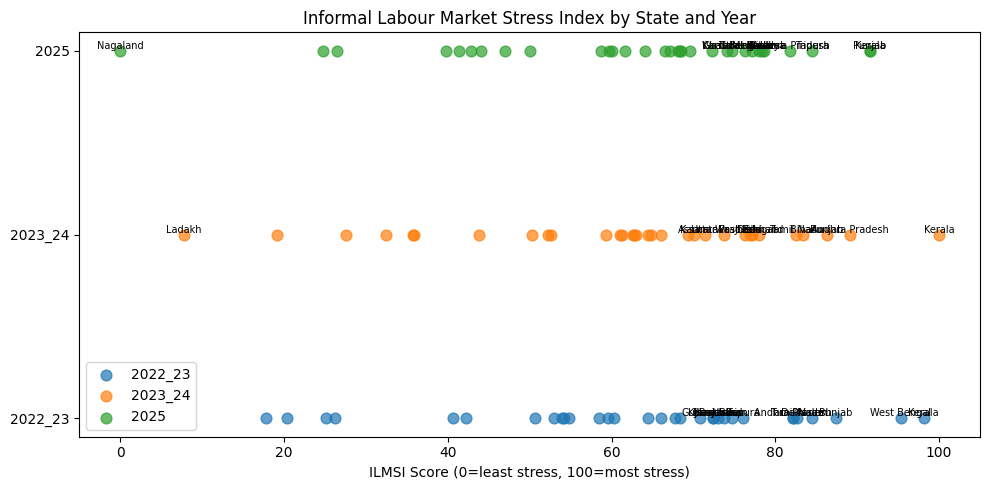

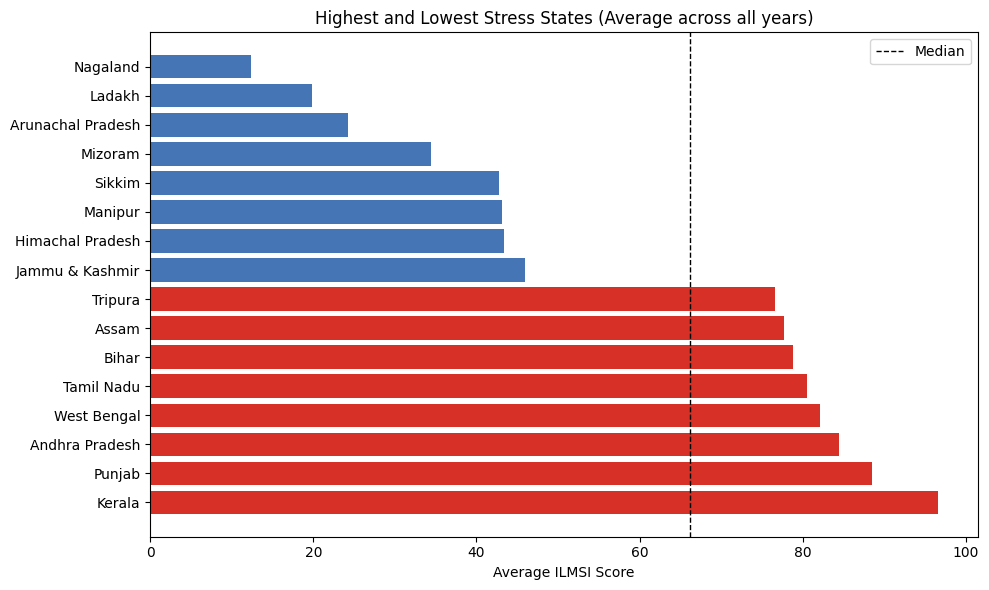

Plots saved.


In [ ]:

import matplotlib.pyplot as plt
import matplotlib.cm as cm

# --- Plot 1: ILMSI distribution by year ---
fig, ax = plt.subplots(figsize=(10, 5))
for year, grp in df_index.groupby('year'):
    ax.scatter(grp['ILMSI'], [year]*len(grp), alpha=0.7, s=60, label=year)
    for _, row in grp.iterrows():
        if row['ILMSI'] > 70 or row['ILMSI'] < 10:
            ax.annotate(row['state'], (row['ILMSI'], year),
                        fontsize=7, ha='center', va='bottom')

ax.set_xlabel("ILMSI Score (0=least stress, 100=most stress)")
ax.set_title("Informal Labour Market Stress Index by State and Year")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(BASE, "ilmsi_scatter.png"), dpi=150)
plt.show()

# --- Plot 2: Top and bottom 8 states (latest year average) ---
avg_by_state = df_index.groupby('state')['ILMSI'].mean().sort_values(ascending=False)
top8 = avg_by_state.head(8)
bot8 = avg_by_state.tail(8)
plot_data = pd.concat([top8, bot8])

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#d73027' if v > avg_by_state.median() else '#4575b4' for v in plot_data.values]
ax.barh(plot_data.index, plot_data.values, color=colors)
ax.axvline(avg_by_state.median(), color='black', linestyle='--', linewidth=1, label='Median')
ax.set_xlabel("Average ILMSI Score")
ax.set_title("Highest and Lowest Stress States (Average across all years)")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(BASE, "ilmsi_bar.png"), dpi=150)
plt.show()

print("Plots saved.")

In [17]:
# Check correlations between index components and ILMSI
import pandas as pd
import numpy as np

corr_check = df_index[[ 'wage_precarity', 
                         'informality', 'casual_share', 
                         'self_reg_ratio', 'ILMSI']].corr()

print("Correlations with ILMSI:")
print(corr_check['ILMSI'].sort_values())

print("\nCorrelation matrix between components:")
cols = ['wage_precarity', 'informality', 'casual_share', 'self_reg_ratio']
print(corr_check.loc[cols, cols].round(3))

Correlations with ILMSI:
self_reg_ratio   -0.818462
informality       0.504219
casual_share      0.665197
wage_precarity    0.736388
ILMSI             1.000000
Name: ILMSI, dtype: float64

Correlation matrix between components:
                wage_precarity  informality  casual_share  self_reg_ratio
wage_precarity           1.000        0.117         0.219          -0.568
informality              0.117        1.000         0.322          -0.193
casual_share             0.219        0.322         1.000          -0.344
self_reg_ratio          -0.568       -0.193        -0.344           1.000


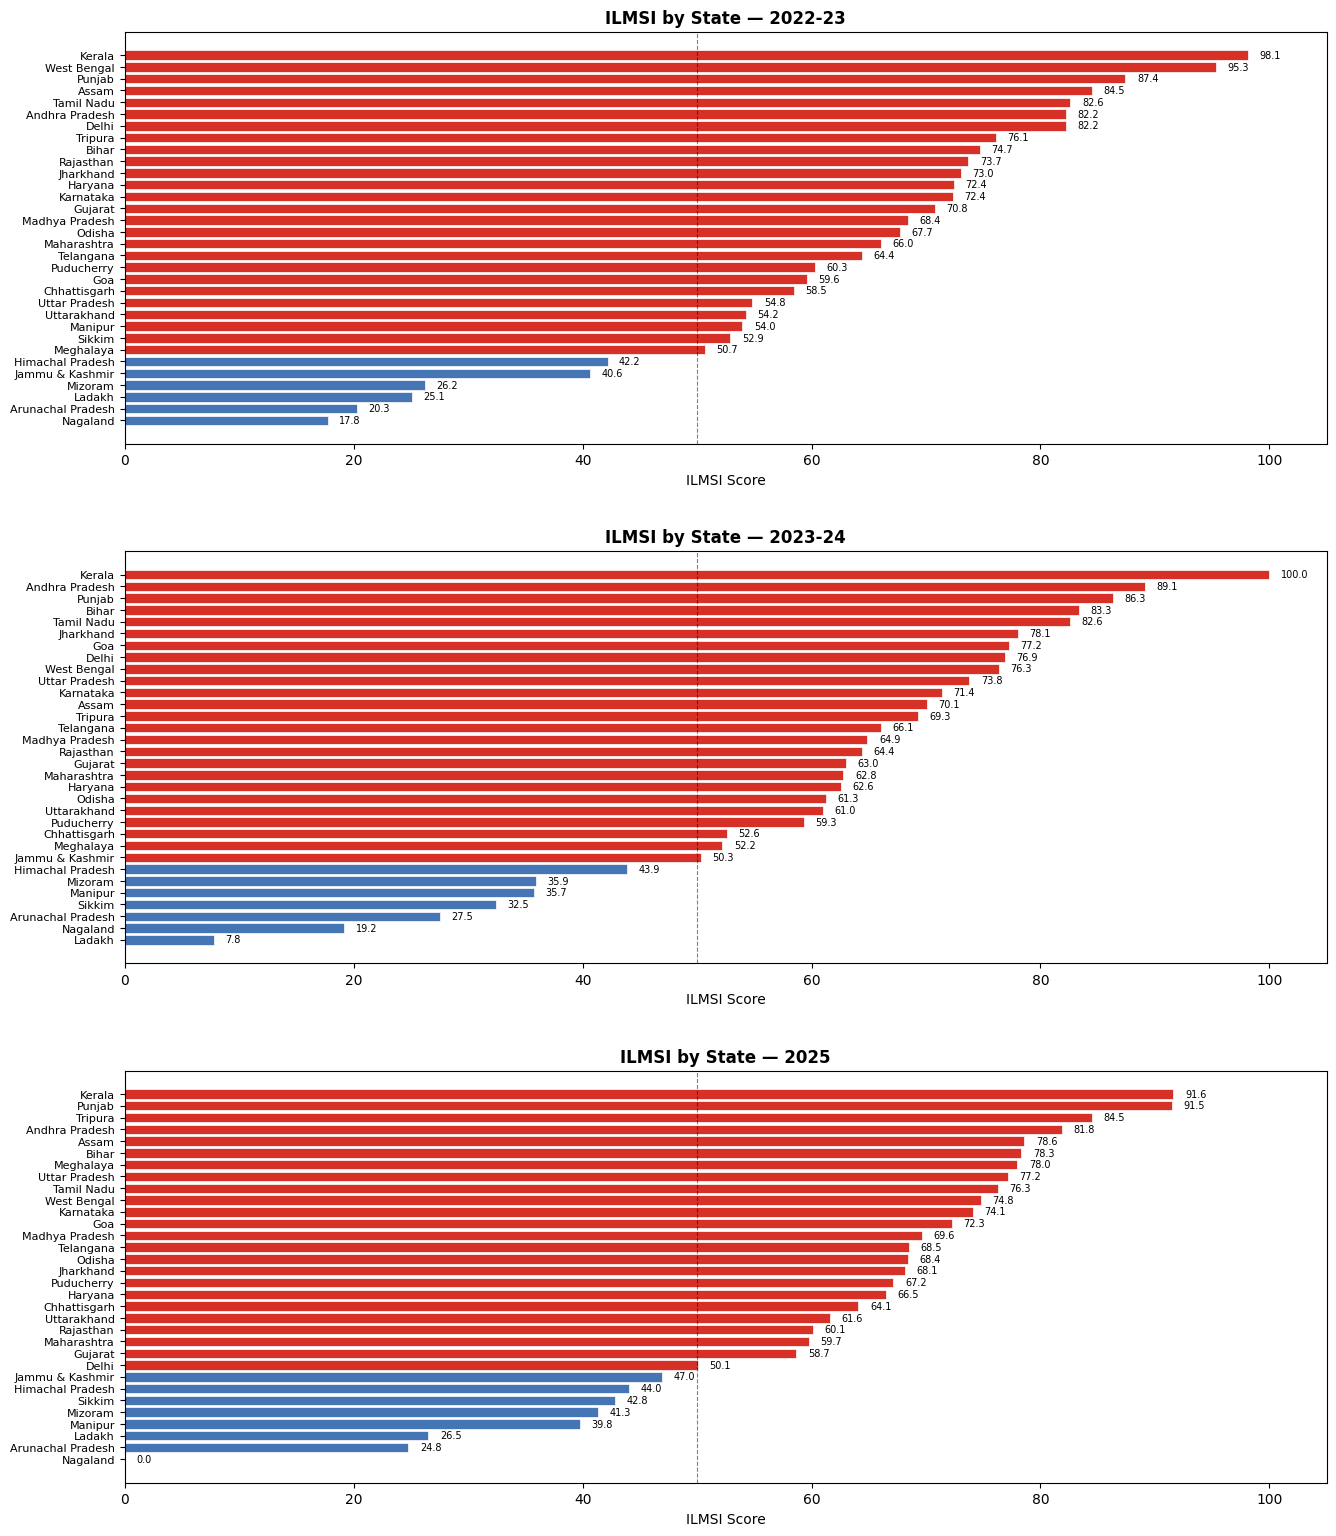

Saved.


In [18]:
import matplotlib.pyplot as plt
import numpy as np

years = df_index['year'].unique()
fig, axes = plt.subplots(3, 1, figsize=(14, 16))

for ax, year in zip(axes, sorted(years)):
    subset = df_index[df_index['year'] == year].sort_values('ILMSI')
    
    colors = ['#d73027' if v > 50 else '#4575b4' for v in subset['ILMSI']]
    
    bars = ax.barh(subset['state'], subset['ILMSI'], 
                   color=colors, edgecolor='white', linewidth=0.5)
    
    ax.axvline(50, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_xlim(0, 105)
    ax.set_xlabel("ILMSI Score", fontsize=10)
    ax.set_title(f"ILMSI by State — {year.replace('_', '-')}", 
                 fontsize=12, fontweight='bold')
    ax.tick_params(axis='y', labelsize=8)
    
    # Add value labels
    for bar, val in zip(bars, subset['ILMSI']):
        ax.text(val + 1, bar.get_y() + bar.get_height()/2, 
                f'{val:.1f}', va='center', fontsize=7)

plt.tight_layout(pad=3.0)
plt.savefig(os.path.join(BASE, "ilmsi_by_year.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [19]:
##PCA CHANGE

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Drop missing rows
df_index = df.dropna(subset=index_vars).copy()

X = df_index[index_vars].values

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Run PCA
pca = PCA(n_components=1)
principal_component = pca.fit_transform(X_scaled)

# Store index
df_index['ILMSI'] = principal_component[:, 0]

In [20]:
# Explained variance
print("Explained variance (PC1):", pca.explained_variance_ratio_[0])

# Loadings
loadings = pd.Series(
    pca.components_[0],
    index=index_vars
)

print("\nPCA Loadings:")
print(loadings.sort_values(ascending=False))

Explained variance (PC1): 0.47721766868239107

PCA Loadings:
self_reg_ratio    0.592393
informality      -0.364948
casual_share     -0.481462
wage_precarity   -0.532989
dtype: float64


# *Index Subsplit into EGI and SII*

In [21]:
#Cell 6 variable construction

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
import numpy as np

# Drop small UTs with unreliable PLFS sample sizes
small_uts = ['Lakshadweep', 'Dadra & Nagar Haveli & Daman & Diu',
             'Andaman & N. Island', 'Chandigarh']
df = master_wide[~master_wide['state'].isin(small_uts)].copy()

# --- Variable construction ---

# Earnings Gap variables (both: higher = more stress)
df['wage_precarity'] = (df['WAGE CASUAL'] * 30) / df['WAGE REGULAR']
df['self_reg_ratio']  = df['WAGE REGULAR'] / df['WAGE SELF']

# Structural Informality variables (both: higher = more stress)
df['casual_share'] = df['EMP STATUS']
df['informality']  = df['ENTERPRISE']

df_index = df[['state', 'year',
               'wage_precarity', 'self_reg_ratio',
               'casual_share', 'informality']].dropna()

print(f"Dataset shape: {df_index.shape}")
print(f"States: {df_index['state'].nunique()}")
print(f"\nDescriptive stats:")
print(df_index[['wage_precarity','self_reg_ratio',
                'casual_share','informality']].describe().round(3))

Dataset shape: (96, 6)
States: 32

Descriptive stats:
       wage_precarity  self_reg_ratio  casual_share  informality
count          96.000          96.000        96.000       96.000
mean            0.744           1.641        17.244       67.528
std             0.187           0.700         8.124       12.114
min             0.341           0.506         4.300       37.500
25%             0.611           1.206         9.775       59.350
50%             0.730           1.473        17.900       68.500
75%             0.849           1.908        23.025       76.725
max             1.300           4.527        39.100       89.400


In [22]:
#Cell 7: Build both sub-indices and composite
def build_subindex(df, vars, name, negate_if_needed=True):
    """
    Standardise variables, run PCA, extract PC1, rescale to 0-100.
    Automatically orients so that higher score = more stress.
    """
    scaler = StandardScaler()
    X = scaler.fit_transform(df[vars].values)
    
    pca = PCA(n_components=1)
    scores = pca.fit_transform(X).flatten()
    
    # Check orientation: if PC1 negatively correlates with first var, flip
    if np.corrcoef(scores, df[vars[0]].values)[0,1] < 0:
        scores = -scores
    
    # Rescale to 0-100
    scores = (scores - scores.min()) / (scores.max() - scores.min()) * 100
    
    print(f"\n{name}")
    print(f"  PC1 variance explained: {pca.explained_variance_ratio_[0]:.3f}")
    print(f"  Loadings:")
    for v, l in zip(vars, pca.components_[0]):
        # Adjust sign for display if we flipped
        corr_sign = np.sign(np.corrcoef(scores, df[v].values)[0,1])
        print(f"    {v:20s}: {l * corr_sign:+.3f}")
    
    return scores

# Build sub-indices
df_index = df_index.copy()

df_index['EGI'] = build_subindex(
    df_index,
    ['wage_precarity', 'self_reg_ratio'],
    "Earnings Gap Index (EGI)"
)

df_index['SII'] = build_subindex(
    df_index,
    ['casual_share', 'informality'],
    "Structural Informality Index (SII)"
)

# Composite: simple average of both sub-indices
df_index['ILMSI'] = (df_index['EGI'] + df_index['SII']) / 2

print(f"\n--- Composite ILMSI (average of EGI and SII) ---")
print(f"\nTop 10 highest stress:")
print(df_index[['state','year','EGI','SII','ILMSI']]
      .sort_values('ILMSI', ascending=False).head(10).to_string())
print(f"\nTop 10 lowest stress:")
print(df_index[['state','year','EGI','SII','ILMSI']]
      .sort_values('ILMSI').head(10).to_string())

# Save
index_path = os.path.join(BASE, "plfs_ilmsi.csv")
df_index.to_csv(index_path, index=False)
print(f"\nSaved: {index_path}")


Earnings Gap Index (EGI)
  PC1 variance explained: 0.784
  Loadings:
    wage_precarity      : -0.707
    self_reg_ratio      : -0.707

Structural Informality Index (SII)
  PC1 variance explained: 0.661
  Loadings:
    casual_share        : +0.707
    informality         : +0.707

--- Composite ILMSI (average of EGI and SII) ---

Top 10 highest stress:
              state     year        EGI         SII      ILMSI
48           Kerala  2022_23  92.563325   77.940087  85.251706
49           Kerala  2023_24  99.897468   70.489826  85.193647
105     West Bengal  2022_23  87.700027   80.863305  84.281666
9             Assam  2022_23  61.574737  100.000000  80.787368
4    Andhra Pradesh  2023_24  78.638362   79.753986  79.196174
13            Bihar  2023_24  66.520255   91.183069  78.851662
83           Punjab     2025  91.153647   66.293454  78.723550
50           Kerala     2025  93.102268   63.196521  78.149395
81           Punjab  2022_23  83.103507   69.807539  76.455523
3    Andhra Pr

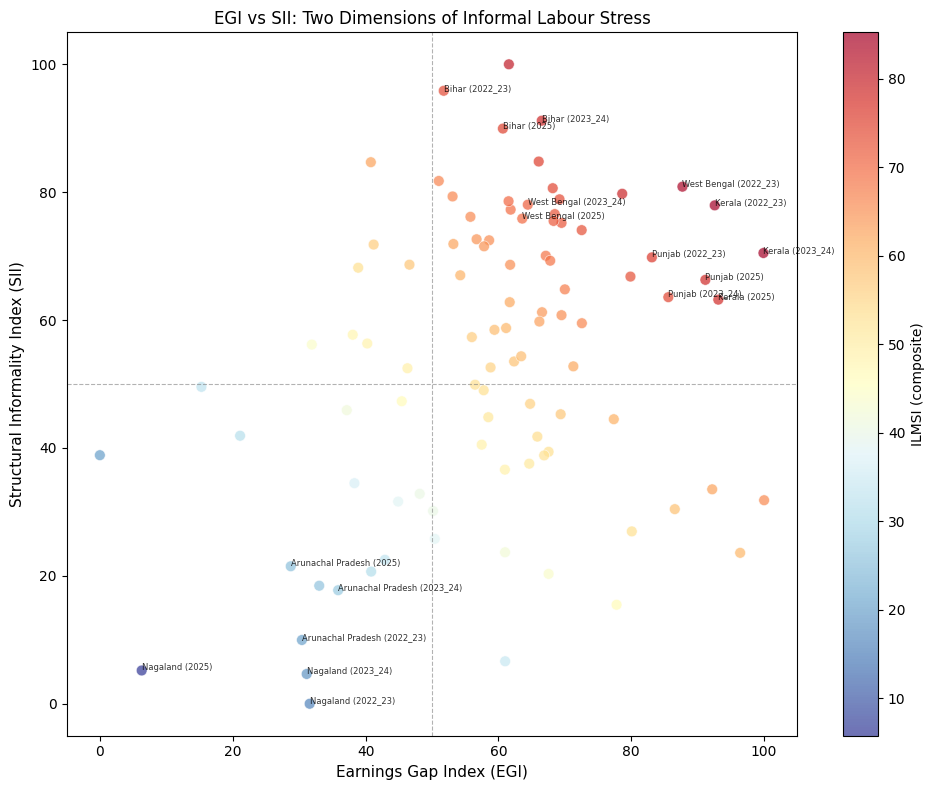

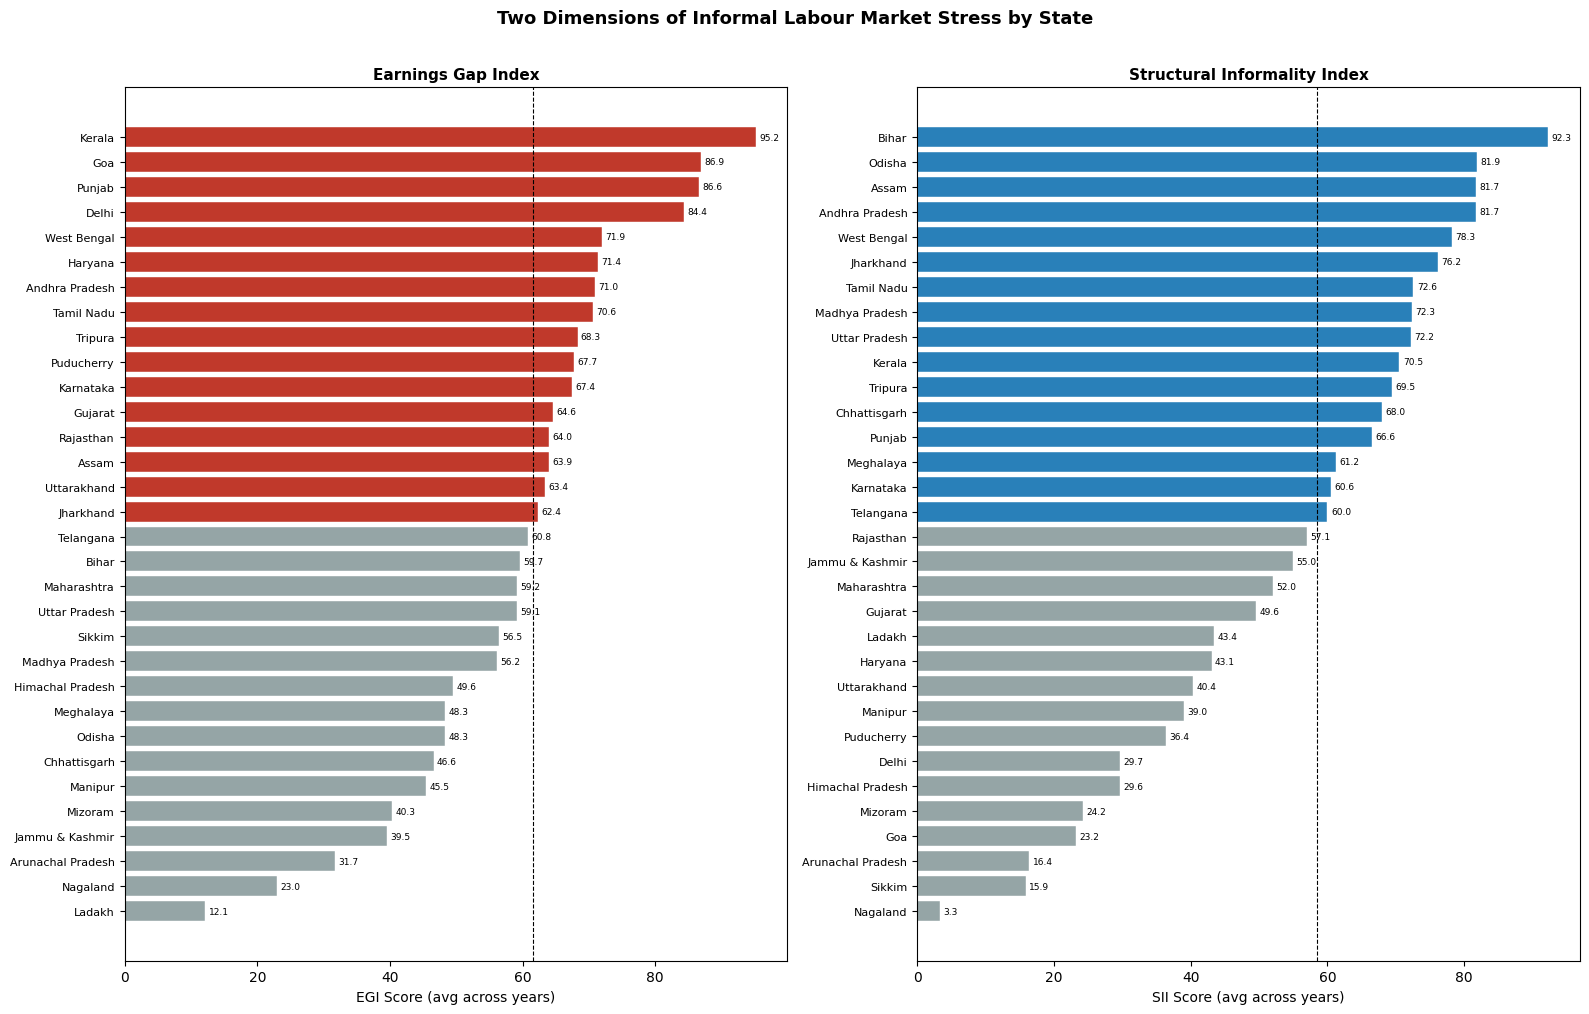

In [23]:
#Cell 8: Visualisation 
import matplotlib.pyplot as plt

years = sorted(df_index['year'].unique())
avg = df_index.groupby('state')[['EGI','SII','ILMSI']].mean().sort_values('ILMSI')

# --- Chart 1: EGI vs SII scatter (all state-years) ---
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(df_index['EGI'], df_index['SII'],
                     c=df_index['ILMSI'], cmap='RdYlBu_r',
                     s=60, alpha=0.7, edgecolors='white', linewidth=0.5)
plt.colorbar(scatter, label='ILMSI (composite)')
ax.axvline(50, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axhline(50, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_xlabel("Earnings Gap Index (EGI)", fontsize=11)
ax.set_ylabel("Structural Informality Index (SII)", fontsize=11)
ax.set_title("EGI vs SII: Two Dimensions of Informal Labour Stress", fontsize=12)

# Label a few key states
for _, row in df_index.iterrows():
    if row['state'] in ['Kerala', 'Punjab', 'Bihar', 'Nagaland',
                        'West Bengal', 'Arunachal Pradesh']:
        ax.annotate(f"{row['state']} ({row['year']})",
                    (row['EGI'], row['SII']),
                    fontsize=6, alpha=0.8)

plt.tight_layout()
plt.savefig(os.path.join(BASE, "egi_vs_sii.png"), dpi=150, bbox_inches='tight')
plt.show()

# --- Chart 2: Side by side EGI and SII bar charts (average across years) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

for ax, col, title, color_high in zip(
    axes,
    ['EGI', 'SII'],
    ['Earnings Gap Index', 'Structural Informality Index'],
    ['#c0392b', '#2980b9']
):
    data = df_index.groupby('state')[col].mean().sort_values()
    colors = [color_high if v > data.median() else '#95a5a6' for v in data.values]
    bars = ax.barh(data.index, data.values, color=colors, edgecolor='white', linewidth=0.3)
    ax.axvline(data.median(), color='black', linestyle='--', linewidth=0.8)
    ax.set_xlabel(f"{col} Score (avg across years)", fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.tick_params(axis='y', labelsize=8)
    for bar, val in zip(bars, data.values):
        ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}', va='center', fontsize=6.5)

plt.suptitle("Two Dimensions of Informal Labour Market Stress by State",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(BASE, "egi_sii_bars.png"), dpi=150, bbox_inches='tight')
plt.show()



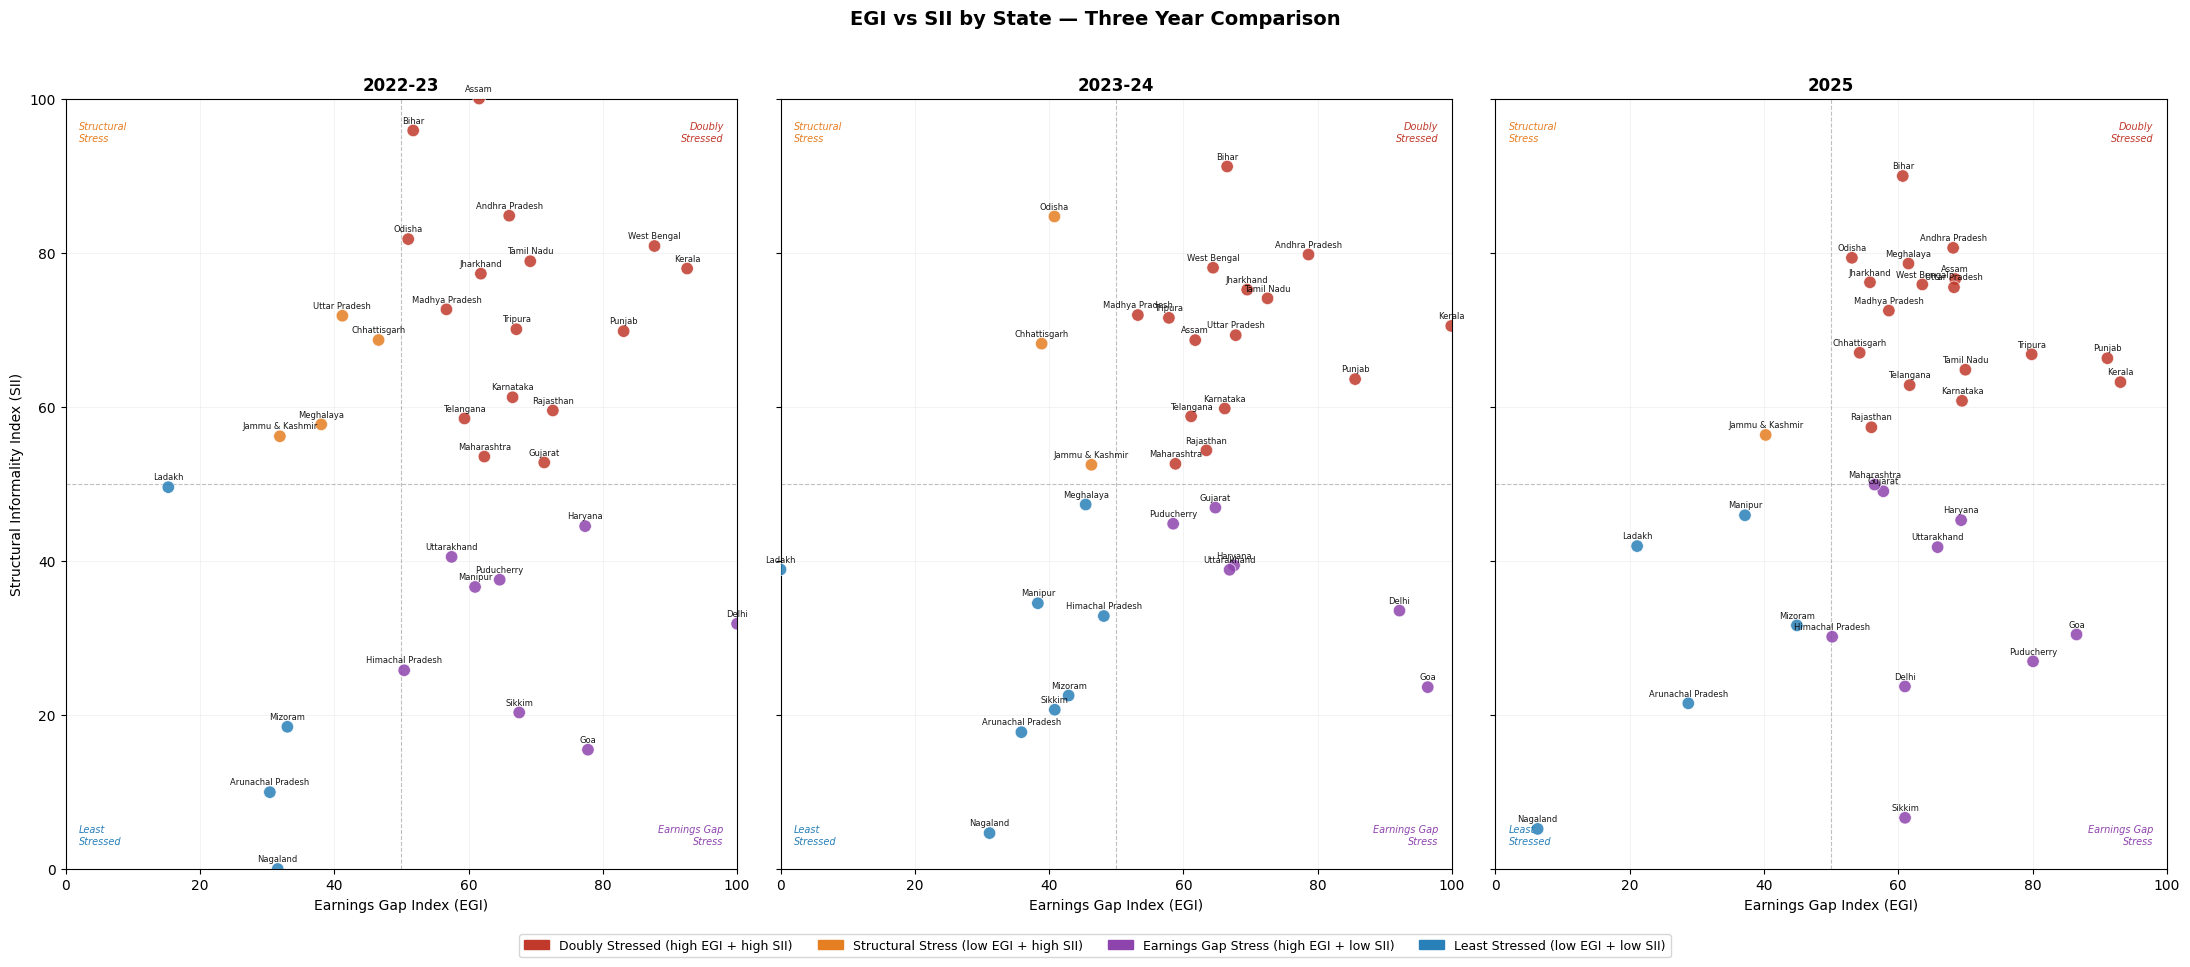

Saved.


In [24]:
#Plot for all three years, each point labelled
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

years = sorted(df_index['year'].unique())
fig, axes = plt.subplots(1, 3, figsize=(22, 9), sharey=True, sharex=True)

for ax, year in zip(axes, years):
    subset = df_index[df_index['year'] == year].copy()
    
    # Color by quadrant
    colors = []
    for _, row in subset.iterrows():
        if row['EGI'] >= 50 and row['SII'] >= 50:
            colors.append('#c0392b')    # top right: doubly stressed
        elif row['EGI'] < 50 and row['SII'] >= 50:
            colors.append('#e67e22')    # top left: structural stress
        elif row['EGI'] >= 50 and row['SII'] < 50:
            colors.append('#8e44ad')    # bottom right: earnings gap stress
        else:
            colors.append('#2980b9')    # bottom left: least stressed
    
    ax.scatter(subset['EGI'], subset['SII'],
               c=colors, s=80, alpha=0.85,
               edgecolors='white', linewidth=0.5, zorder=3)
    
    # Label every point
    for _, row in subset.iterrows():
        ax.annotate(
            row['state'],
            (row['EGI'], row['SII']),
            fontsize=6,
            ha='center',
            va='bottom',
            xytext=(0, 4),
            textcoords='offset points',
            alpha=0.9
        )
    
    # Quadrant lines
    ax.axvline(50, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axhline(50, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
    
    # Quadrant labels
    ax.text(2, 97, 'Structural\nStress', fontsize=7, color='#e67e22',
            va='top', style='italic')
    ax.text(98, 97, 'Doubly\nStressed', fontsize=7, color='#c0392b',
            va='top', ha='right', style='italic')
    ax.text(2, 3, 'Least\nStressed', fontsize=7, color='#2980b9',
            va='bottom', style='italic')
    ax.text(98, 3, 'Earnings Gap\nStress', fontsize=7, color='#8e44ad',
            va='bottom', ha='right', style='italic')
    
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_xlabel("Earnings Gap Index (EGI)", fontsize=10)
    if ax == axes[0]:
        ax.set_ylabel("Structural Informality Index (SII)", fontsize=10)
    ax.set_title(f"{year.replace('_', '-')}", fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.2, linewidth=0.5)

# Legend
patches = [
    mpatches.Patch(color='#c0392b', label='Doubly Stressed (high EGI + high SII)'),
    mpatches.Patch(color='#e67e22', label='Structural Stress (low EGI + high SII)'),
    mpatches.Patch(color='#8e44ad', label='Earnings Gap Stress (high EGI + low SII)'),
    mpatches.Patch(color='#2980b9', label='Least Stressed (low EGI + low SII)'),
]
fig.legend(handles=patches, loc='lower center', ncol=4,
           fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.04))

plt.suptitle("EGI vs SII by State — Three Year Comparison",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(BASE, "egi_sii_by_year.png"),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

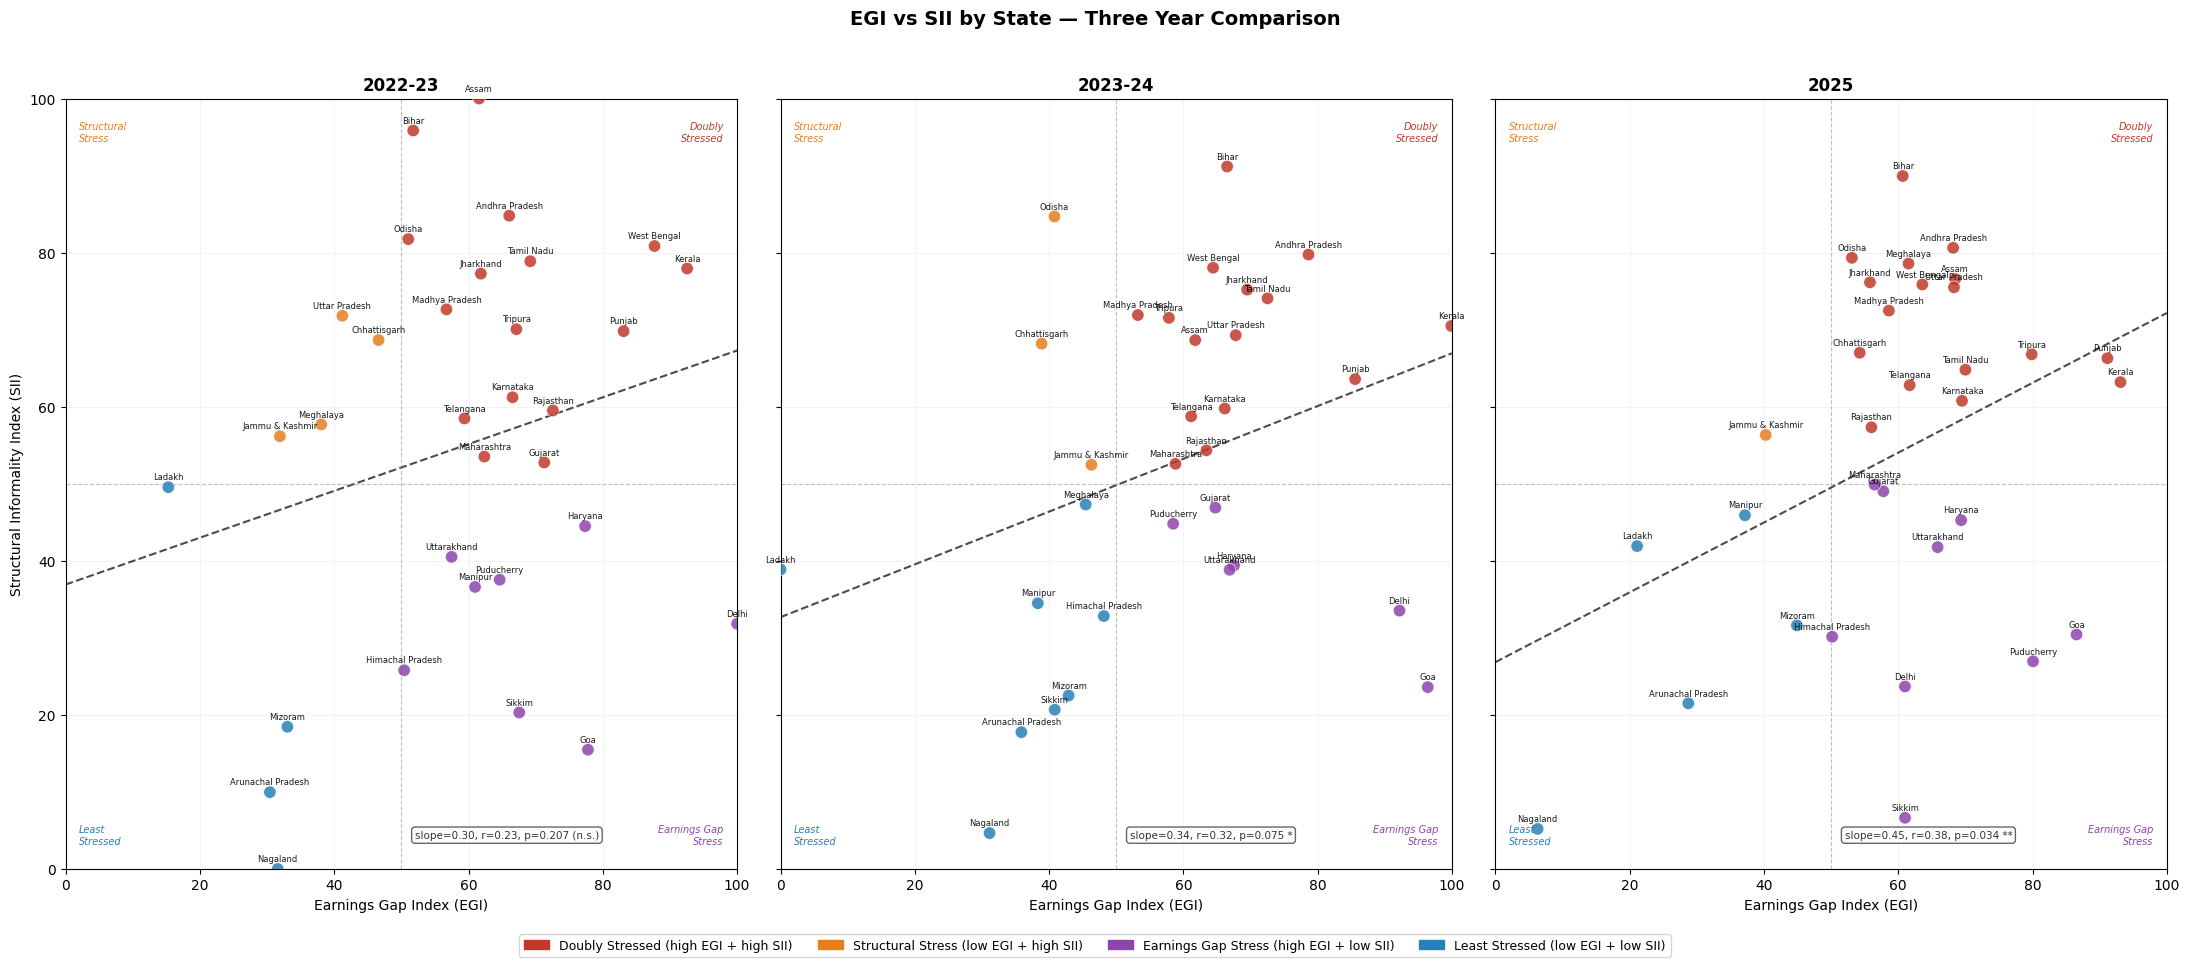

Saved.


In [25]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from scipy import stats

years = sorted(df_index['year'].unique())
fig, axes = plt.subplots(1, 3, figsize=(22, 9), sharey=True, sharex=True)

for ax, year in zip(axes, years):
    subset = df_index[df_index['year'] == year].copy()
    
    # Color by quadrant
    colors = []
    for _, row in subset.iterrows():
        if row['EGI'] >= 50 and row['SII'] >= 50:
            colors.append('#c0392b')
        elif row['EGI'] < 50 and row['SII'] >= 50:
            colors.append('#e67e22')
        elif row['EGI'] >= 50 and row['SII'] < 50:
            colors.append('#8e44ad')
        else:
            colors.append('#2980b9')
    
    ax.scatter(subset['EGI'], subset['SII'],
               c=colors, s=80, alpha=0.85,
               edgecolors='white', linewidth=0.5, zorder=3)
    
    # Label every point
    for _, row in subset.iterrows():
        ax.annotate(
            row['state'],
            (row['EGI'], row['SII']),
            fontsize=6,
            ha='center',
            va='bottom',
            xytext=(0, 4),
            textcoords='offset points',
            alpha=0.9
        )
    
    # --- Trendline ---
    x = subset['EGI'].values
    y = subset['SII'].values
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    x_line = np.linspace(0, 100, 200)
    y_line = slope * x_line + intercept
    # Only draw where y_line is within bounds
    mask = (y_line >= 0) & (y_line <= 100)
    sig_label = '***' if p_value < 0.01 else '**' if p_value < 0.05 else '*' if p_value < 0.1 else '(n.s.)'
    ax.plot(x_line[mask], y_line[mask],
            color='black', linewidth=1.5, linestyle='--', alpha=0.7, zorder=2)
    ax.text(52, 4,
            f'slope={slope:.2f}, r={r_value:.2f}, p={p_value:.3f} {sig_label}',
            fontsize=7.5, color='black', alpha=0.8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.6))
    
    # Quadrant lines
    ax.axvline(50, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axhline(50, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
    
    # Quadrant labels
    ax.text(2, 97, 'Structural\nStress', fontsize=7, color='#e67e22',
            va='top', style='italic')
    ax.text(98, 97, 'Doubly\nStressed', fontsize=7, color='#c0392b',
            va='top', ha='right', style='italic')
    ax.text(2, 3, 'Least\nStressed', fontsize=7, color='#2980b9',
            va='bottom', style='italic')
    ax.text(98, 3, 'Earnings Gap\nStress', fontsize=7, color='#8e44ad',
            va='bottom', ha='right', style='italic')
    
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_xlabel("Earnings Gap Index (EGI)", fontsize=10)
    if ax == axes[0]:
        ax.set_ylabel("Structural Informality Index (SII)", fontsize=10)
    ax.set_title(f"{year.replace('_', '-')}", fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.2, linewidth=0.5)

# Legend
patches = [
    mpatches.Patch(color='#c0392b', label='Doubly Stressed (high EGI + high SII)'),
    mpatches.Patch(color='#e67e22', label='Structural Stress (low EGI + high SII)'),
    mpatches.Patch(color='#8e44ad', label='Earnings Gap Stress (high EGI + low SII)'),
    mpatches.Patch(color='#2980b9', label='Least Stressed (low EGI + low SII)'),
]
fig.legend(handles=patches, loc='lower center', ncol=4,
           fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.04))

plt.suptitle("EGI vs SII by State — Three Year Comparison",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(BASE, "egi_sii_trendlines.png"),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [26]:
import pandas as pd

lit = pd.read_excel(r"C:\Projects\PLFS\Table29.6-States.xlsx")

# Keep needed columns
lit = lit[[
    'All India/State/Union Territory',
    '2011 - Rural - Person',
    '2011 - Urban - Persons'
]]

# Rename
lit = lit.rename(columns={
    'All India/State/Union Territory': 'state',
    '2011 - Rural - Person': 'lit_rural',
    '2011 - Urban - Persons': 'lit_urban'
})

print(lit.head())

               state  lit_rural  lit_urban
0          All India         68         84
1     Andhra Pradesh         60         80
2  Arunachal Pradesh         60         83
3              Assam         69         89
4              Bihar         60         77


In [27]:
lit['literacy'] = (lit['lit_rural'] + lit['lit_urban']) / 2

In [28]:
# Drop All India
lit = lit[lit['state'] != 'All India']

# Clean state names
lit['state'] = lit['state'].str.strip()

lit = lit[['state', 'literacy']].reset_index(drop=True)

print(lit.head())

               state  literacy
0     Andhra Pradesh      70.0
1  Arunachal Pradesh      71.5
2              Assam      79.0
3              Bihar      68.5
4        Chhatisgarh      75.0


In [29]:
state_map = {
    "Jammu & Kashmir": "Jammu and Kashmir",
    "A. and N. Islands": "A & N Islands",
    "Daman and Diu": "Daman & Diu",
}

lit['state'] = lit['state'].replace(state_map)
df_index['state'] = df_index['state'].replace(state_map)

In [30]:
df = df_index.merge(lit, on='state', how='left')

print(df[['state', 'literacy']].head(20))

                state  literacy
0      Andhra Pradesh      70.0
1      Andhra Pradesh      70.0
2      Andhra Pradesh      70.0
3   Arunachal Pradesh      71.5
4   Arunachal Pradesh      71.5
5   Arunachal Pradesh      71.5
6               Assam      79.0
7               Assam      79.0
8               Assam      79.0
9               Bihar      68.5
10              Bihar      68.5
11              Bihar      68.5
12       Chhattisgarh       NaN
13       Chhattisgarh       NaN
14       Chhattisgarh       NaN
15              Delhi      84.0
16              Delhi      84.0
17              Delhi      84.0
18                Goa      88.5
19                Goa      88.5


In [32]:
state_map_extra = {
    "Chhattisgarh": "Chhatisgarh",   # sometimes spelled differently
    "Uttarakhand": "Uttaranchal",
    "Telangana": "Andhra Pradesh",  # Telangana didn't exist in 2011
    "Ladakh": "Jammu and Kashmir"   # same reason
}

df['state'] = df['state'].replace(state_map_extra)

In [33]:
df = df.drop(columns=['literacy'], errors='ignore')
df = df.merge(lit, on='state', how='left')

print("Still missing:")
print(df[df['literacy'].isna()]['state'].unique())

Still missing:
<StringArray>
[]
Length: 0, dtype: str


In [34]:
# Clean INDUSTRY table

ind = pd.read_excel(r"C:\Projects\PLFS\PLFS 23-24 tables\PLFS 23-24 INDUSTRY.xlsx")

# Drop top junk rows
ind_clean = ind.iloc[6:].copy()

# Rename columns
ind_clean.columns = ['state'] + [f'col_{i}' for i in range(1, len(ind_clean.columns))]

# Drop empty rows
ind_clean = ind_clean[ind_clean['state'].notna()]

# Strip state names
ind_clean['state'] = ind_clean['state'].str.strip()

# Agriculture = first column after state
# Agriculture = first column after state
ind_clean['agri_share'] = ind_clean['col_1']

# Convert to numeric (CRITICAL FIX)
ind_clean['agri_share'] = pd.to_numeric(ind_clean['agri_share'], errors='coerce')

# Drop missing values
ind_clean = ind_clean[ind_clean['agri_share'].notna()]

# Keep only needed columns
agri = ind_clean[['state', 'agri_share']]

print(agri.head())
print(agri['agri_share'].describe())

                state  agri_share
6      Andhra Pradesh       53.50
7   Arunachal Pradesh       58.85
8               Assam       34.47
9               Bihar       46.25
10       Chhattisgarh       65.59
count    330.000000
mean      33.937394
std       25.181907
min        0.000000
25%        8.912500
50%       33.895000
75%       53.895000
max       88.650000
Name: agri_share, dtype: float64


In [35]:
print(agri['agri_share'].describe())

count    330.000000
mean      33.937394
std       25.181907
min        0.000000
25%        8.912500
50%       33.895000
75%       53.895000
max       88.650000
Name: agri_share, dtype: float64


In [36]:
agri = agri.groupby('state', as_index=False)['agri_share'].mean()

In [37]:
# Convert to numeric
ind_clean['agri_share'] = pd.to_numeric(ind_clean['col_1'], errors='coerce')

# Drop NA
ind_clean = ind_clean[ind_clean['agri_share'].notna()]

# Keep only needed columns
agri = ind_clean[['state', 'agri_share']]

# Aggregate to one value per state
agri = agri.groupby('state', as_index=False)['agri_share'].mean()

print(agri.head())
print(agri['agri_share'].describe())

                 state  agri_share
0  Andaman & N. Island   26.520000
1       Andhra Pradesh   38.943333
2    Arunachal Pradesh   50.263333
3                Assam   38.455556
4                Bihar   46.822222
count    37.000000
mean     33.631652
std      12.618750
min       0.000000
25%      27.590000
50%      38.301111
75%      39.963333
max      51.406667
Name: agri_share, dtype: float64


In [39]:
agri = agri[agri['agri_share'] > 0]

In [41]:
print(agri.sort_values('agri_share').head())
print(agri.sort_values('agri_share').tail())

          state  agri_share
8         Delhi    1.436667
9           Goa   10.117778
18  Lakshadweep   11.898889
26   Puducherry   13.225556
27       Punjab   24.715556
                state  agri_share
4               Bihar   46.822222
33      Uttar Pradesh   47.353333
2   Arunachal Pradesh   50.263333
6        Chhattisgarh   50.518889
19     Madhya Pradesh   51.406667


In [42]:
df = df.merge(agri, on='state', how='left')

In [43]:
df_reg = df[['SII', 'agri_share', 'literacy']].dropna()

In [45]:
import statsmodels.api as sm
X = df_reg[['agri_share', 'literacy']]
X = sm.add_constant(X)

y = df_reg['SII']

model_sii = sm.OLS(y, X).fit()
print(model_sii.summary())

                            OLS Regression Results                            
Dep. Variable:                    SII   R-squared:                       0.176
Model:                            OLS   Adj. R-squared:                  0.156
Method:                 Least Squares   F-statistic:                     8.652
Date:                Sat, 11 Apr 2026   Prob (F-statistic):           0.000393
Time:                        21:15:38   Log-Likelihood:                -379.12
No. Observations:                  84   AIC:                             764.2
Df Residuals:                      81   BIC:                             771.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        154.0665     38.316      4.021      0.0

In [ ]:
df[['SII', 'agri_share']].corr()

,SII,agri_share
SII,1.000000,0.267857
agri_share,0.267857,1.000000


In [46]:
# Urbanisation rate by state — from PLFS Table 1 or Census
# Use the urban share of population from your existing LFPR file
# as a proxy: urban LFPR observations / total observations
# OR simply add urbanisation data manually from Census 2011 
# (stable enough for a cross-sectional validation)

urban_rates = {
    'Andhra Pradesh': 29.6, 'Arunachal Pradesh': 22.7, 'Assam': 14.1,
    'Bihar': 11.3, 'Chhattisgarh': 23.2, 'Delhi': 97.5, 'Goa': 62.2,
    'Gujarat': 42.6, 'Haryana': 34.9, 'Himachal Pradesh': 10.0,
    'Jammu & Kashmir': 27.4, 'Jharkhand': 24.1, 'Karnataka': 38.6,
    'Kerala': 47.7, 'Madhya Pradesh': 27.6, 'Maharashtra': 45.2,
    'Manipur': 30.2, 'Meghalaya': 20.1, 'Mizoram': 52.1,
    'Nagaland': 28.9, 'Odisha': 16.7, 'Punjab': 37.5,
    'Rajasthan': 24.9, 'Sikkim': 25.2, 'Tamil Nadu': 48.4,
    'Telangana': 38.9, 'Tripura': 26.2, 'Uttar Pradesh': 22.3,
    'Uttarakhand': 30.2, 'West Bengal': 31.9, 'Puducherry': 68.3,
    'Ladakh': 28.0
}

urban_df = pd.DataFrame(list(urban_rates.items()), 
                         columns=['state', 'urban_rate'])

# Average EGI per state across years for cross-sectional validation
egi_avg = df_index.groupby('state')['EGI'].mean().reset_index()
egi_val = egi_avg.merge(urban_df, on='state')

import statsmodels.api as sm
X = sm.add_constant(egi_val[['urban_rate']])
y = egi_val['EGI']
model_egi_valid = sm.OLS(y, X).fit()
print(model_egi_valid.summary())

print(f"\nCorrelation: {egi_val[['EGI','urban_rate']].corr().iloc[0,1]:.3f}")

                            OLS Regression Results                            
Dep. Variable:                    EGI   R-squared:                       0.206
Model:                            OLS   Adj. R-squared:                  0.178
Method:                 Least Squares   F-statistic:                     7.503
Date:                Sat, 11 Apr 2026   Prob (F-statistic):             0.0104
Time:                        21:37:58   Log-Likelihood:                -129.44
No. Observations:                  31   AIC:                             262.9
Df Residuals:                      29   BIC:                             265.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         44.4833      6.339      7.018      0.0

# Validating further using GVA and NREGA card holding data for SII and EGI 

In [54]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import os

BASE = r"C:\Projects\PLFS"

# ── GVA per capita (complete block) ──────────────────────────────────

# Population (Census 2011, in lakhs)
state_population = {
    'Andhra Pradesh': 492.4, 'Arunachal Pradesh': 13.8, 'Assam': 312.1,
    'Bihar': 1040.9, 'Chhattisgarh': 255.5, 'Delhi': 167.5, 'Goa': 14.6,
    'Gujarat': 604.4, 'Haryana': 253.5, 'Himachal Pradesh': 68.6,
    'Jammu & Kashmir': 125.4, 'Jharkhand': 329.9, 'Karnataka': 610.1,
    'Kerala': 333.4, 'Madhya Pradesh': 724.6, 'Maharashtra': 1123.7,
    'Manipur': 28.6, 'Meghalaya': 29.7, 'Mizoram': 10.9,
    'Nagaland': 19.8, 'Odisha': 419.7, 'Punjab': 277.4,
    'Rajasthan': 685.2, 'Sikkim': 6.1, 'Tamil Nadu': 721.5,
    'Telangana': 350.0, 'Tripura': 36.7, 'Uttar Pradesh': 1998.1,
    'Uttarakhand': 100.9, 'West Bengal': 912.8,
    'Puducherry': 12.5, 'Ladakh': 2.7
}
pop_df = pd.DataFrame(list(state_population.items()),
                      columns=['state', 'population_lakh'])

# Load GVA file
gva_raw = pd.read_excel(os.path.join(BASE, "gva.xlsx"),
                        sheet_name="T_26(ii)", header=None)
rows = gva_raw.values.tolist()
year_cols = rows[5][2:]

gva_data = []
for row in rows[6:39]:
    state = row[1]
    if not isinstance(state, str):
        continue
    if state.startswith('-') or state.startswith('Source'):
        continue
    entry = {'state': state.replace('*', '').strip()}
    for yr, val in zip(year_cols, row[2:]):
        if isinstance(yr, str) and yr != 'Base: 2011-12':
            entry[yr] = val if isinstance(val, (int, float)) else np.nan
    gva_data.append(entry)

gva = pd.DataFrame(gva_data)

# Per capita: GVA in lakh rupees / population in lakhs = rupees per person
gva_pc = gva[['state', '2022-23']].copy()
gva_pc.columns = ['state', 'gva_2022_23']
gva_pc = gva_pc.merge(pop_df, on='state', how='left')
gva_pc['gva_per_capita'] = gva_pc['gva_2022_23'] / gva_pc['population_lakh']

print("GVA per capita (Rs per person, 2022-23, constant prices):")
print(gva_pc[['state', 'gva_per_capita']]
      .sort_values('gva_per_capita', ascending=False).to_string())

# ── EGI validation regression ─────────────────────────────────────────
urban_rates = {
    'Andhra Pradesh': 29.6, 'Arunachal Pradesh': 22.7, 'Assam': 14.1,
    'Bihar': 11.3, 'Chhattisgarh': 23.2, 'Delhi': 97.5, 'Goa': 62.2,
    'Gujarat': 42.6, 'Haryana': 34.9, 'Himachal Pradesh': 10.0,
    'Jammu & Kashmir': 27.4, 'Jharkhand': 24.1, 'Karnataka': 38.6,
    'Kerala': 47.7, 'Madhya Pradesh': 27.6, 'Maharashtra': 45.2,
    'Manipur': 30.2, 'Meghalaya': 20.1, 'Mizoram': 52.1,
    'Nagaland': 28.9, 'Odisha': 16.7, 'Punjab': 37.5,
    'Rajasthan': 24.9, 'Sikkim': 25.2, 'Tamil Nadu': 48.4,
    'Telangana': 38.9, 'Tripura': 26.2, 'Uttar Pradesh': 22.3,
    'Uttarakhand': 30.2, 'West Bengal': 31.9, 'Puducherry': 68.3,
    'Ladakh': 28.0
}
urban_df = pd.DataFrame(list(urban_rates.items()),
                         columns=['state', 'urban_rate'])

# Average EGI per state across all years
egi_avg = df_index.groupby('state')['EGI'].mean().reset_index()

# Merge
egi_val = (egi_avg
    .merge(urban_df,  on='state', how='left')
    .merge(gva_pc[['state', 'gva_per_capita']], on='state', how='left')
)

print(f"\nEGI validation dataset shape: {egi_val.shape}")
print(f"Missing values:\n{egi_val.isnull().sum()}")

# Correlation check first
print(f"\nCorrelations:")
print(f"  EGI vs urban_rate:     {egi_val[['EGI','urban_rate']].corr().iloc[0,1]:+.3f}")
print(f"  EGI vs gva_per_capita: {egi_val[['EGI','gva_per_capita']].corr().iloc[0,1]:+.3f}")

# Regression
import statsmodels.api as sm

egi_data = egi_val[['EGI', 'urban_rate', 'gva_per_capita']].dropna()
X_egi = sm.add_constant(egi_data[['urban_rate', 'gva_per_capita']])
model_egi = sm.OLS(egi_data['EGI'], X_egi).fit()

print("\n" + "="*65)
print("VALIDATION REGRESSION: EGI ~ urban_rate + gva_per_capita")
print("="*65)
print(model_egi.summary())

GVA per capita (Rs per person, 2022-23, constant prices):
                        state  gva_per_capita
8                         Goa   370174.863014
26                     Sikkim   360043.606557
7                       Delhi   320711.158209
10                    Haryana   205881.420118
14                  Karnataka   202332.306179
9                     Gujarat   200536.800132
28                  Telangana   186493.674286
23                 Puducherry   180515.840000
17                Maharashtra   179107.004539
11           Himachal Pradesh   178367.274052
27                 Tamil Nadu   176403.304227
31                Uttarakhand   175087.026759
20                    Mizoram   169881.376147
15                     Kerala   160264.340132
24                     Punjab   153086.164384
1              Andhra Pradesh   139880.060926
2           Arunachal Pradesh   128036.376812
29                    Tripura   111604.223433
25                  Rajasthan   106083.941915
6                Chhat

In [55]:
# Check correlation between the two predictors
print("Correlation between urban_rate and gva_per_capita:")
print(f"  r = {egi_val[['urban_rate','gva_per_capita']].corr().iloc[0,1]:+.3f}")

# If highly correlated (above 0.7), we should run them separately
# rather than together in one regression

print("\nCorrelations with EGI:")
print(f"  EGI vs urban_rate:     {egi_val[['EGI','urban_rate']].corr().iloc[0,1]:+.3f}")
print(f"  EGI vs gva_per_capita: {egi_val[['EGI','gva_per_capita']].corr().iloc[0,1]:+.3f}")

Correlation between urban_rate and gva_per_capita:
  r = +0.629

Correlations with EGI:
  EGI vs urban_rate:     +0.453
  EGI vs gva_per_capita: +0.407


In [56]:
import statsmodels.api as sm
import numpy as np

# Standardise gva_per_capita to fix numerical scale issue
egi_val['gva_pc_std'] = (
    (egi_val['gva_per_capita'] - egi_val['gva_per_capita'].mean()) 
    / egi_val['gva_per_capita'].std()
)

egi_data = egi_val[['EGI', 'urban_rate', 'gva_pc_std']].dropna()
X_egi = sm.add_constant(egi_data[['urban_rate', 'gva_pc_std']])
model_egi = sm.OLS(egi_data['EGI'], X_egi).fit()

print("="*65)
print("VALIDATION REGRESSION: EGI ~ urban_rate + gva_per_capita")
print(f"N = {len(egi_data)} states")
print("="*65)
print(f"R-squared:     {model_egi.rsquared:.3f}")
print(f"Adj R-squared: {model_egi.rsquared_adj:.3f}")
print(f"F-statistic:   {model_egi.fvalue:.3f}  (p={model_egi.f_pvalue:.4f})")
print()
print(f"{'Variable':<20} {'Coef':>8} {'SE':>8} {'t':>8} {'p':>8} {'Sig':>5}")
print("-"*65)
for var in model_egi.params.index:
    coef = model_egi.params[var]
    se   = model_egi.bse[var]
    t    = model_egi.tvalues[var]
    p    = model_egi.pvalues[var]
    sig  = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else ''
    print(f"{var:<20} {coef:>8.3f} {se:>8.3f} {t:>8.3f} {p:>8.4f} {sig:>5}")
print("="*65)
print("Note: gva_per_capita standardised (mean=0, sd=1) for numerical stability")
print(f"\nCorrelations with EGI:")
print(f"  urban_rate:     {egi_val[['EGI','urban_rate']].corr().iloc[0,1]:+.3f}")
print(f"  gva_per_capita: {egi_val[['EGI','gva_per_capita']].corr().iloc[0,1]:+.3f}")

VALIDATION REGRESSION: EGI ~ urban_rate + gva_per_capita
N = 30 states
R-squared:     0.253
Adj R-squared: 0.198
F-statistic:   4.580  (p=0.0194)

Variable                 Coef       SE        t        p   Sig
-----------------------------------------------------------------
const                  50.153    6.881    7.289   0.0000   ***
urban_rate              0.329    0.185    1.778   0.0867     *
gva_pc_std              2.673    3.398    0.787   0.4383      
Note: gva_per_capita standardised (mean=0, sd=1) for numerical stability

Correlations with EGI:
  urban_rate:     +0.453
  gva_per_capita: +0.407


In [58]:
# ── NREGA job card coverage (complete block) ──────────────────────────

import openpyxl

nrega_name_map = {
    'ANDAMAN AND NICOBAR':  'Andaman & N. Island',
    'ANDHRA PRADESH':       'Andhra Pradesh',
    'ARUNACHAL PRADESH':    'Arunachal Pradesh',
    'ASSAM':                'Assam',
    'BIHAR':                'Bihar',
    'CHHATTISGARH':         'Chhattisgarh',
    'DN HAVELI AND DD':     'Dadra & Nagar Haveli & Daman & Diu',
    'GOA':                  'Goa',
    'GUJARAT':              'Gujarat',
    'HARYANA':              'Haryana',
    'HIMACHAL PRADESH':     'Himachal Pradesh',
    'JAMMU AND KASHMIR':    'Jammu & Kashmir',
    'JHARKHAND':            'Jharkhand',
    'KARNATAKA':            'Karnataka',
    'KERALA':               'Kerala',
    'LADAKH':               'Ladakh',
    'LAKSHADWEEP':          'Lakshadweep',
    'MADHYA PRADESH':       'Madhya Pradesh',
    'MAHARASHTRA':          'Maharashtra',
    'MANIPUR':              'Manipur',
    'MEGHALAYA':            'Meghalaya',
    'MIZORAM':              'Mizoram',
    'NAGALAND':             'Nagaland',
    'ODISHA':               'Odisha',
    'PUDUCHERRY':           'Puducherry',
    'PUNJAB':               'Punjab',
    'RAJASTHAN':            'Rajasthan',
    'SIKKIM':               'Sikkim',
    'TAMIL NADU':           'Tamil Nadu',
    'TELANGANA':            'Telangana',
    'TRIPURA':              'Tripura',
    'UTTAR PRADESH':        'Uttar Pradesh',
    'UTTARAKHAND':          'Uttarakhand',
    'WEST BENGAL':          'West Bengal',
}

wb = openpyxl.load_workbook(os.path.join(BASE, "NREGA job-holding coverage.xlsx"))
ws = wb.active
rows_n = list(ws.iter_rows(values_only=True))

nrega_data = []
for row in rows_n[4:]:
    state_raw = row[1]
    issued    = row[3]
    if not isinstance(state_raw, str):
        continue
    if state_raw.strip().upper() == 'TOTAL':
        continue
    plfs_name = nrega_name_map.get(state_raw.strip().upper())
    if plfs_name is None:
        print(f"Unmapped: {state_raw}")
        continue
    nrega_data.append({
        'state':           plfs_name,
        'jobcards_lakh':   issued if isinstance(issued, (int, float)) else np.nan
    })

nrega_df = pd.DataFrame(nrega_data)

# Coverage = job cards issued (lakh) / population (lakh)
# = job cards per person — multiply by 100 to get cards per 100 people
nrega_df = nrega_df.merge(pop_df, on='state', how='left')
nrega_df['nrega_per100'] = (
    nrega_df['jobcards_lakh'] / nrega_df['population_lakh'] * 100
)

print("NREGA job cards per 100 population:")
print(nrega_df[['state','nrega_per100']]
      .sort_values('nrega_per100', ascending=False).to_string())

# ── SII validation regression ─────────────────────────────────────────
literacy_data = {
    'Andhra Pradesh': 67.4, 'Arunachal Pradesh': 65.4, 'Assam': 73.2,
    'Bihar': 63.8, 'Chhattisgarh': 71.0, 'Delhi': 86.2, 'Goa': 88.7,
    'Gujarat': 79.3, 'Haryana': 76.6, 'Himachal Pradesh': 83.8,
    'Jammu & Kashmir': 68.7, 'Jharkhand': 67.6, 'Karnataka': 75.6,
    'Kerala': 94.0, 'Madhya Pradesh': 70.6, 'Maharashtra': 82.9,
    'Manipur': 79.9, 'Meghalaya': 75.5, 'Mizoram': 91.6,
    'Nagaland': 80.1, 'Odisha': 73.5, 'Punjab': 76.7,
    'Rajasthan': 66.1, 'Sikkim': 82.2, 'Tamil Nadu': 80.3,
    'Telangana': 72.8, 'Tripura': 87.8, 'Uttar Pradesh': 67.7,
    'Uttarakhand': 79.6, 'West Bengal': 77.1, 'Puducherry': 86.6,
    'Ladakh': 77.2
}
literacy_df = pd.DataFrame(list(literacy_data.items()),
                            columns=['state', 'literacy'])

# Average SII and agri_share per state
sii_avg  = df_index.groupby('state')['SII'].mean().reset_index()
agri_avg = df.groupby('state')['agri_share'].mean().reset_index()

sii_val = (sii_avg
    .merge(literacy_df, on='state', how='left')
    .merge(agri_avg,    on='state', how='left')
    .merge(nrega_df[['state','nrega_per100']], on='state', how='left')
)

print(f"\nSII validation dataset: {sii_val.shape}")
print(f"Missing values:\n{sii_val.isnull().sum()}")

# Correlations
print(f"\nCorrelations with SII:")
print(f"  literacy:      {sii_val[['SII','literacy']].corr().iloc[0,1]:+.3f}")
print(f"  agri_share:    {sii_val[['SII','agri_share']].corr().iloc[0,1]:+.3f}")
print(f"  nrega_per100:  {sii_val[['SII','nrega_per100']].corr().iloc[0,1]:+.3f}")

# Regression
sii_data = sii_val[['SII','literacy','agri_share','nrega_per100']].dropna()
X_sii = sm.add_constant(sii_data[['literacy','agri_share','nrega_per100']])
model_sii = sm.OLS(sii_data['SII'], X_sii).fit()

print("\n" + "="*65)
print("VALIDATION REGRESSION: SII ~ literacy + agri_share + nrega_per100")
print(f"N = {len(sii_data)} states")
print("="*65)
print(f"R-squared:     {model_sii.rsquared:.3f}")
print(f"Adj R-squared: {model_sii.rsquared_adj:.3f}")
print(f"F-statistic:   {model_sii.fvalue:.3f}  (p={model_sii.f_pvalue:.4f})")
print()
print(f"{'Variable':<20} {'Coef':>8} {'SE':>8} {'t':>8} {'p':>8} {'Sig':>5}")
print("-"*65)
for var in model_sii.params.index:
    coef = model_sii.params[var]
    se   = model_sii.bse[var]
    t    = model_sii.tvalues[var]
    p    = model_sii.pvalues[var]
    sig  = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else ''
    print(f"{var:<20} {coef:>8.3f} {se:>8.3f} {t:>8.3f} {p:>8.4f} {sig:>5}")
print("="*65)

NREGA job cards per 100 population:
                                 state  nrega_per100
2                    Arunachal Pradesh     26.449275
20                           Meghalaya     23.939394
22                            Nagaland     23.484848
19                             Manipur     22.342657
10                    Himachal Pradesh     21.574344
3                                Assam     21.073374
12                           Jharkhand     19.969688
21                             Mizoram     19.633028
30                             Tripura     18.746594
26                           Rajasthan     17.231465
4                                Bihar     17.055433
5                         Chhattisgarh     15.158513
23                              Odisha     15.106028
33                         West Bengal     14.962752
29                           Telangana     14.888571
15                              Ladakh     13.703704
27                              Sikkim     13.442623
1         

In [59]:
# ── Full SII regression summary ───────────────────────────────────────
print("="*65)
print("VALIDATION REGRESSION: SII ~ literacy + agri_share + nrega_per100")
print(f"N = {len(sii_data)} states")
print("="*65)
print(f"R-squared:     {model_sii.rsquared:.3f}")
print(f"Adj R-squared: {model_sii.rsquared_adj:.3f}")
print(f"F-statistic:   {model_sii.fvalue:.3f}  (p={model_sii.f_pvalue:.4f})")
print()
print(f"{'Variable':<20} {'Coef':>8} {'SE':>8} {'t':>8} {'p':>8} {'Sig':>5}")
print("-"*65)
for var in model_sii.params.index:
    coef = model_sii.params[var]
    se   = model_sii.bse[var]
    t    = model_sii.tvalues[var]
    p    = model_sii.pvalues[var]
    sig  = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else ''
    print(f"{var:<20} {coef:>8.3f} {se:>8.3f} {t:>8.3f} {p:>8.4f} {sig:>5}")
print("="*65)

# ── Separate simple regressions for each predictor ────────────────────
print("\n" + "="*65)
print("SIMPLE REGRESSIONS (each predictor alone)")
print("="*65)

simple_vars = {
    'literacy':     sii_val[['SII','literacy']].dropna(),
    'agri_share':   sii_val[['SII','agri_share']].dropna(),
    'nrega_per100': sii_val[['SII','nrega_per100']].dropna(),
}

for var_name, data in simple_vars.items():
    X = sm.add_constant(data[[var_name]])
    y = data['SII']
    m = sm.OLS(y, X).fit()
    coef = m.params[var_name]
    se   = m.bse[var_name]
    t    = m.tvalues[var_name]
    p    = m.pvalues[var_name]
    r2   = m.rsquared
    sig  = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else '(n.s.)'
    print(f"\nSII ~ {var_name}")
    print(f"  N={len(data)}  R²={r2:.3f}  coef={coef:+.3f}  "
          f"SE={se:.3f}  t={t:.3f}  p={p:.4f}  {sig}")

# ── Same for EGI ──────────────────────────────────────────────────────
print("\n" + "="*65)
print("SIMPLE REGRESSIONS FOR EGI")
print("="*65)

egi_simple_vars = {
    'urban_rate':    egi_val[['EGI','urban_rate']].dropna(),
    'gva_per_capita': egi_val[['EGI','gva_per_capita']].dropna(),
}

for var_name, data in egi_simple_vars.items():
    X = sm.add_constant(data[[var_name]])
    y = data['EGI']
    m = sm.OLS(y, X).fit()
    coef = m.params[var_name]
    se   = m.bse[var_name]
    t    = m.tvalues[var_name]
    p    = m.pvalues[var_name]
    r2   = m.rsquared
    sig  = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else '(n.s.)'
    print(f"\nEGI ~ {var_name}")
    print(f"  N={len(data)}  R²={r2:.3f}  coef={coef:+.3f}  "
          f"SE={se:.3f}  t={t:.3f}  p={p:.4f}  {sig}")

# ── Final correlation table ───────────────────────────────────────────
print("\n" + "="*65)
print("CORRELATION SUMMARY")
print("="*65)
pairs = [
    ('SII', 'literacy',      sii_val),
    ('SII', 'agri_share',    sii_val),
    ('SII', 'nrega_per100',  sii_val),
    ('EGI', 'urban_rate',    egi_val),
    ('EGI', 'gva_per_capita',egi_val),
]
for dep, ind, df_v in pairs:
    r = df_v[[dep, ind]].corr().iloc[0,1]
    print(f"  {dep} vs {ind:<20}: {r:+.3f}")

VALIDATION REGRESSION: SII ~ literacy + agri_share + nrega_per100
N = 26 states
R-squared:     0.229
Adj R-squared: 0.123
F-statistic:   2.173  (p=0.1199)

Variable                 Coef       SE        t        p   Sig
-----------------------------------------------------------------
const                 150.372   72.158    2.084   0.0490    **
literacy               -1.169    0.727   -1.608   0.1220      
agri_share              0.340    0.762    0.446   0.6600      
nrega_per100           -1.159    0.958   -1.209   0.2394      

SIMPLE REGRESSIONS (each predictor alone)

SII ~ literacy
  N=31  R²=0.201  coef=-1.316  SE=0.487  t=-2.702  p=0.0114  **

SII ~ agri_share
  N=27  R²=0.074  coef=+0.568  SE=0.402  t=1.412  p=0.1703  (n.s.)

SII ~ nrega_per100
  N=30  R²=0.009  coef=-0.377  SE=0.733  t=-0.514  p=0.6114  (n.s.)

SIMPLE REGRESSIONS FOR EGI

EGI ~ urban_rate
  N=31  R²=0.206  coef=+0.450  SE=0.164  t=2.739  p=0.0104  **

EGI ~ gva_per_capita
  N=30  R²=0.166  coef=+0.000  SE=0.